In [1]:
import numpy as np
from qiskit import QuantumCircuit,execute
from qiskit.visualization import plot_histogram
from qiskit_aer import Aer
from qiskit.visualization import plot_bloch_multivector
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import DCXGate, iSwapGate
import matplotlib.pyplot as plt
%matplotlib inline

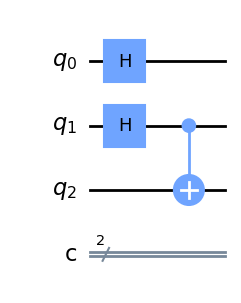

In [2]:
qc = QuantumCircuit(3,2)
qc.h(0)
qc.h(1)
qc.cx(1,2)
qc.draw('mpl')

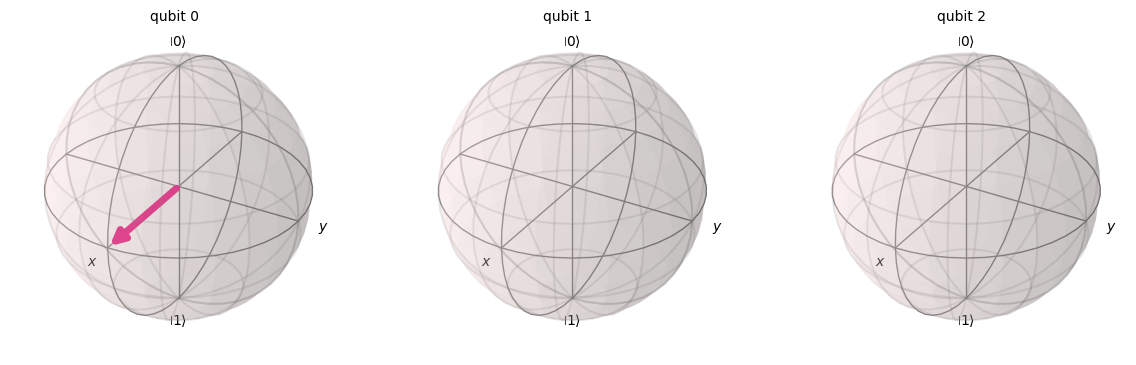

In [3]:
state = Statevector.from_instruction(qc)
plot_bloch_multivector(state)

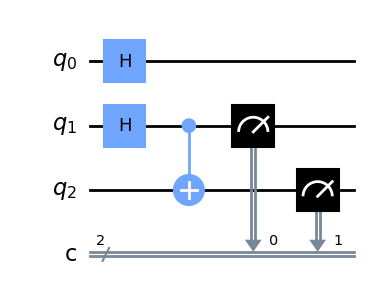

In [4]:
qc.measure(1,0)
qc.measure(2,1)
qc.draw("mpl")

{'00': 493, '11': 507}


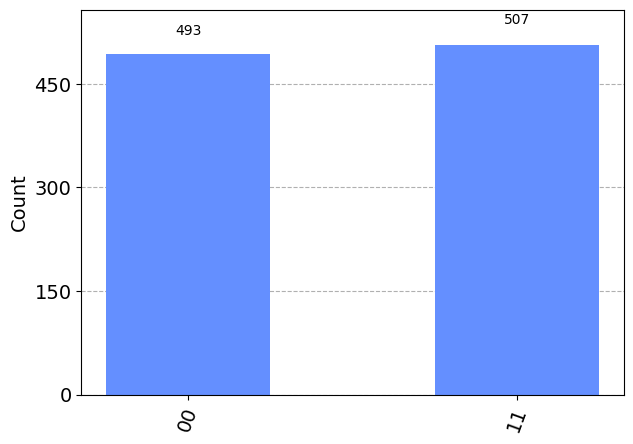

In [5]:
simulator = Aer.get_backend('qasm_simulator')
result = execute(qc,simulator,shots=1000).result()
counts = result.get_counts()
print(counts)
plot_histogram(counts)

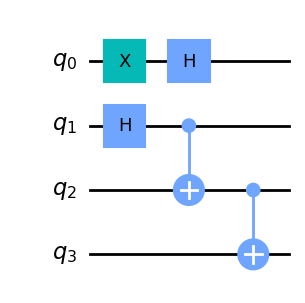

In [6]:
#نسخه تعمیم یافته مدار بالا با 4 کیوبیت
qc1= QuantumCircuit(4)
qc1.x(0)
qc1.h(0)

qc1.h(1)
qc1.cx(1,2)
qc1.cx(2,3)
qc1.draw('mpl')

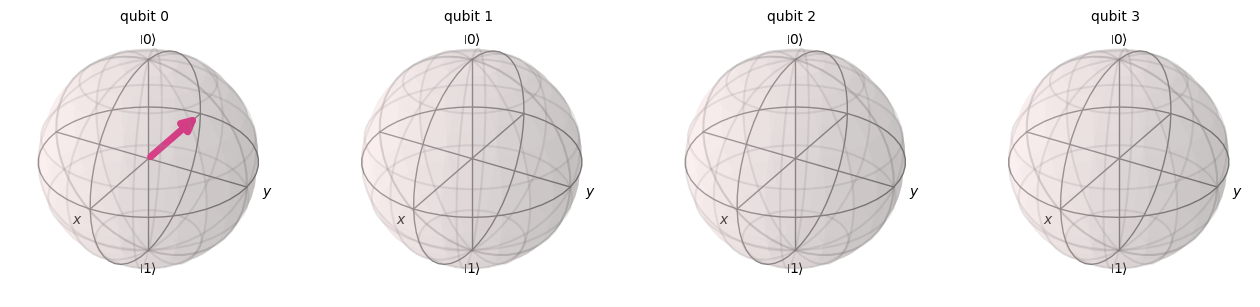

In [7]:
state = Statevector.from_instruction(qc1)
plot_bloch_multivector(state)

In [8]:
simulator = Aer.get_backend('statevector_simulator')
result = execute(qc,simulator).result()
statevector = result.get_statevector()
print(statevector)

Statevector([0.70710678+0.j, 0.70710678+0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j],
            dims=(2, 2, 2))


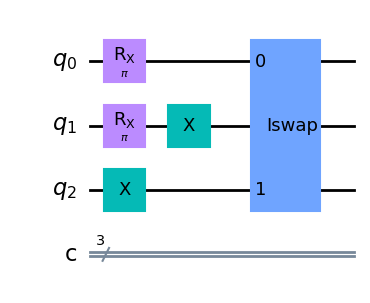

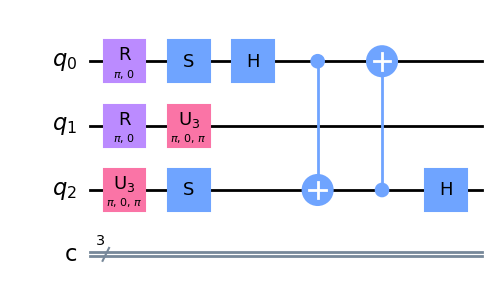

In [127]:
#سوالات بخش 4
#سوال1
#پیاده سازی با الگوی داده شده iswap
qc = QuantumCircuit(3,3)
qc.rx(np.pi, 0)
qc.rx(np.pi, 1)
qc.x([1,2])
qc.append(iSwapGate(), [0,2])

display(qc.draw('mpl'))
decomposed_qc = qc.decompose()

display(decomposed_qc.draw('mpl'))

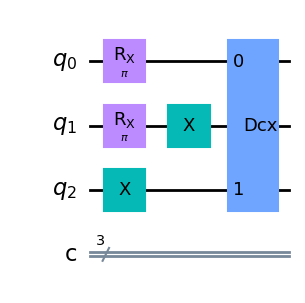

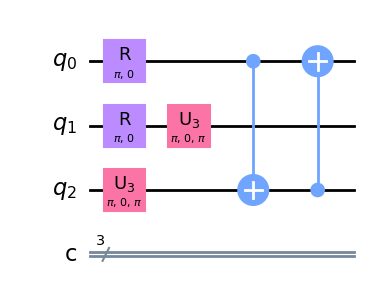

In [135]:
#پیاده سازی با الگوی داده شده dxc
qc=QuantumCircuit(3,3)
qc.rx(np.pi,[0,1])
qc.x([1,2])
qc.append(DCXGate(),[0,2])

display(qc.draw('mpl'))
decomposed_qc=qc.decompose()
display(decomposed_qc.draw('mpl'))

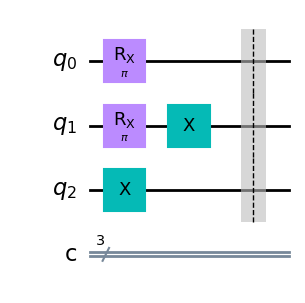

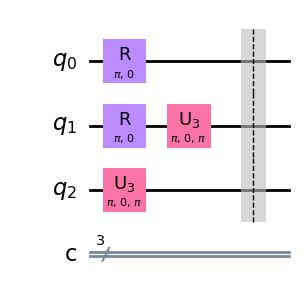

In [147]:
#پیاده سازی barrier
qc= QuantumCircuit(3,3)
qc.rx(np.pi,[0,1])
qc.x([1,2])
qc.barrier()

display(qc.draw('mpl'))
decomposed_qc = qc.decompose()
display(decomposed_qc.draw('mpl'))

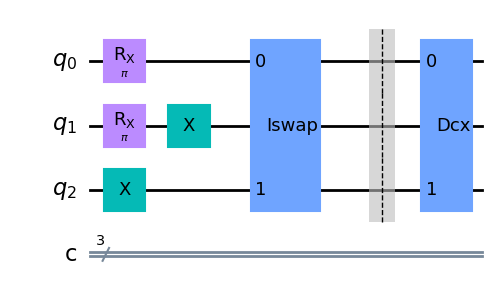

In [149]:
#پیاده سازی iswap,dcx,barrier
new_qc= QuantumCircuit(3,3)
new_qc.rx(np.pi,[0,1])
new_qc.x([1,2])
new_qc.append(iSwapGate(),[0,2])
new_qc.barrier()
new_qc.append(DCXGate(),[0,2])

display(new_qc.draw('mpl'))


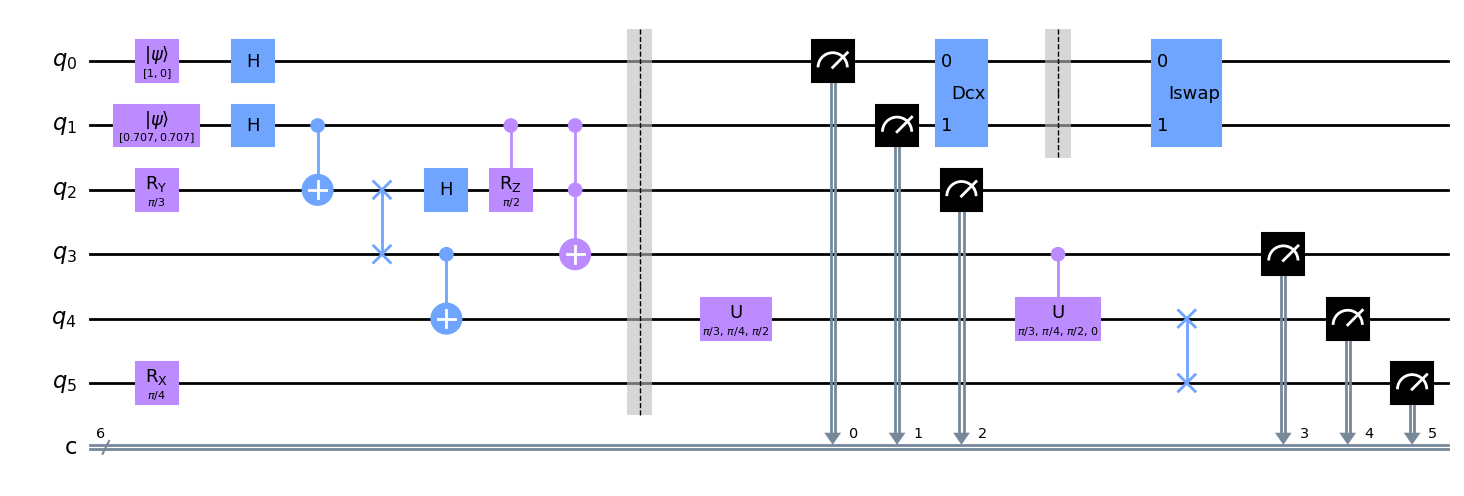

In [125]:
#سوال2
qc = QuantumCircuit(6,6)

initial_state=[1,0]
qc.initialize(initial_state,0)
initial_state=[1/np.sqrt(2),1/np.sqrt(2)]
qc.initialize(initial_state,1)
qc.h(0)
qc.h(1)
qc.ry(np.pi/3,2)
qc.cx(1,2)
qc.swap(2,3)
qc.h(2)
qc.cx(3,4)
qc.crz(np.pi/2,1,2)
qc.ccx(1,2,3)
qc.rx(np.pi/4,5)


qc.barrier()
qc.u(np.pi/3,np.pi/4,np.pi/2,4)
qc.measure(0,0)
qc.measure(1,1)
qc.measure(2,2)
qc.append(DCXGate(), [0,1])
qc.cu(np.pi/3,np.pi/4,np.pi/2,0,3,4)
qc.barrier([0,1])
qc.swap(4,5)
qc.measure(3,3)
qc.measure(4,4)
qc.measure(5,5)

qc.append(iSwapGate(), [0,1])


qc.draw('mpl')

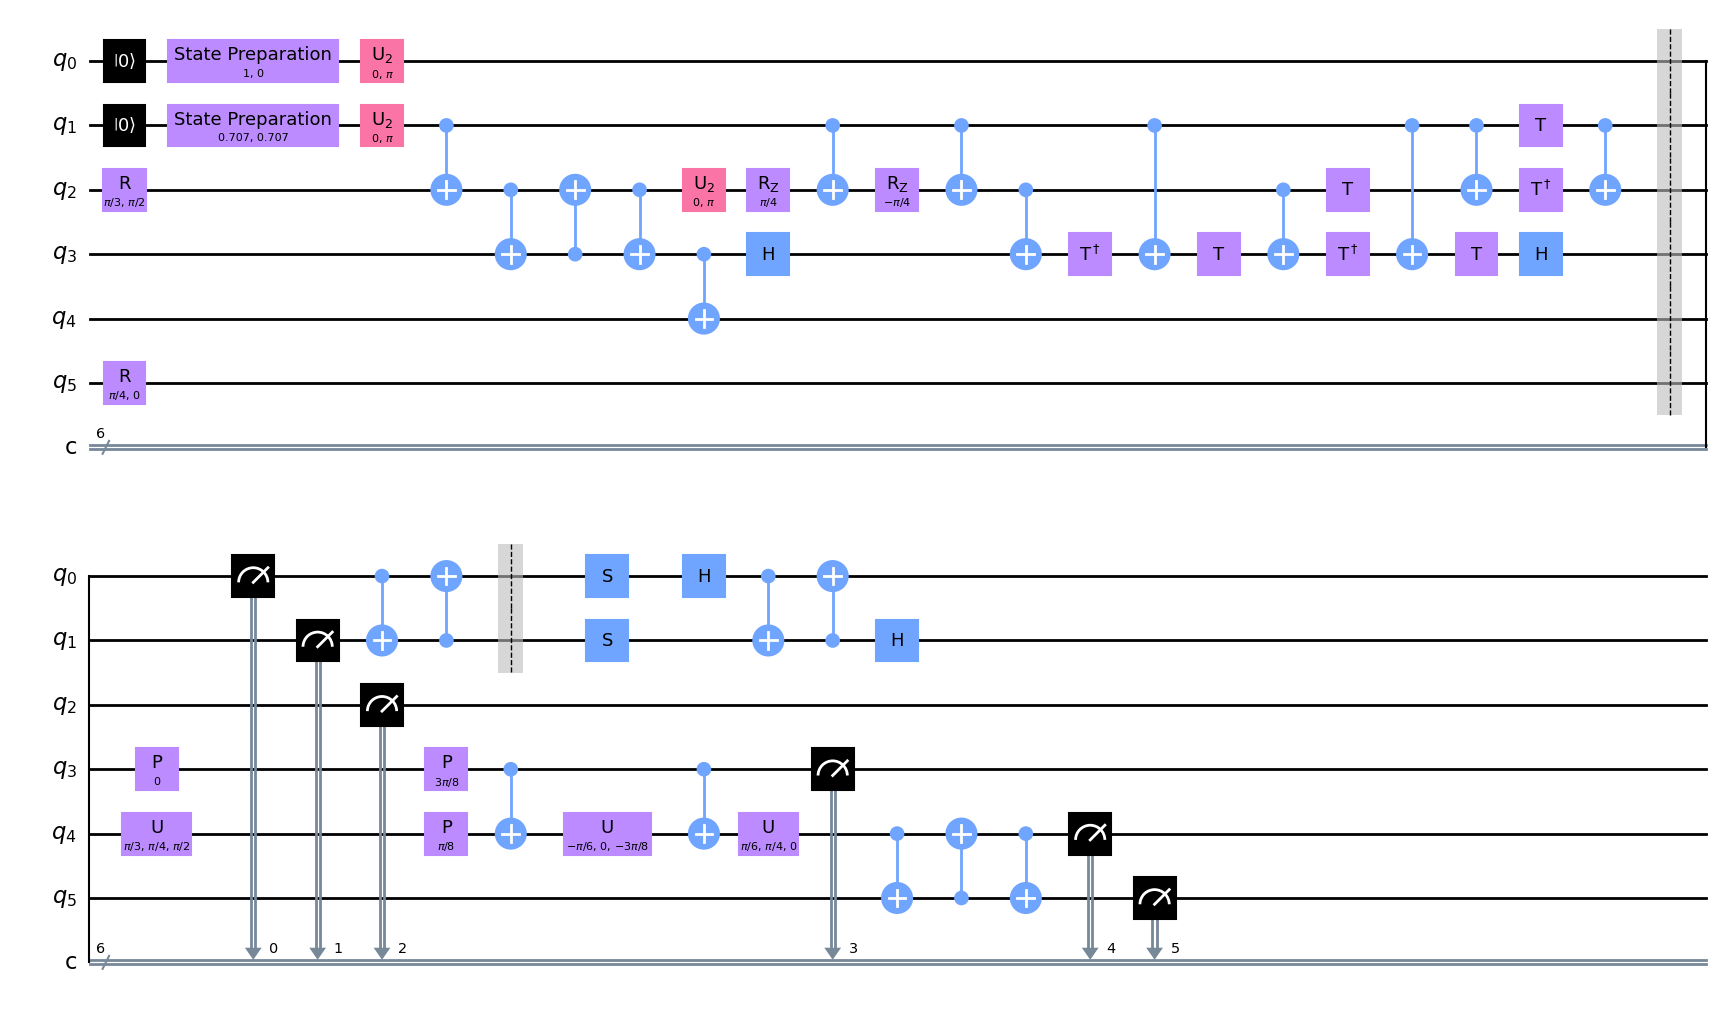

In [116]:
decomposed_qc = qc.decompose()
display(decomposed_qc.draw('mpl'))